In [268]:
import os
import re
import pandas as pd
file = "årsutfall.1997-2024.csv"

df = pd.read_csv(file, sep=";",
    encoding="utf-8-sig",
    engine="python")

print(df.shape)
print(df.columns)
df.head()

(15322, 17)
Index(['Utgiftsområde', 'Utgiftsområdesnamn', 'Anslag', 'Anslagsnamn', 'År',
       'Ingående överföringsbelopp', 'Statens budget', 'Ändringsbudgetar',
       'Indragningar', 'Utnyttjad del av medgivet överskridande', 'Utfall',
       'Anslagskredit', 'Utgående överföringsbelopp',
       'Utgiftsområde utfallsår', 'Utgiftsområdesnamn utfallsår',
       'Anslag utfallsår', 'Anslagsnamn utfallsår'],
      dtype='str')


,Utgiftsområde,Utgiftsområdesnamn,Anslag,Anslagsnamn,År,Ingående överföringsbelopp,Statens budget,Ändringsbudgetar,Indragningar,Utnyttjad del av medgivet överskridande,Utfall,Anslagskredit,Utgående överföringsbelopp,Utgiftsområde utfallsår,Utgiftsområdesnamn utfallsår,Anslag utfallsår,Anslagsnamn utfallsår
0,NaN,Utgiftstak,NaN,Utgiftstak,1997,NaN,723000,NaN,NaN,NaN,723000,NaN,NaN,NaN,Utgiftstak,NaN,Utgiftstak
1,NaN,Marginal till utgiftstaket,NaN,Marginal till utgiftstaket,1997,NaN,"10501,557",NaN,NaN,NaN,"24107,98769888",NaN,NaN,NaN,Marginal till utgiftstaket,NaN,Marginal till utgiftstaket
2,NaN,Kassamässig korrigering,NaN,Kassamässig korrigering,1997,NaN,86691,NaN,NaN,NaN,"-1960,878",NaN,NaN,NaN,Kassamässig korrigering,NaN,Kassamässig korrigering
3,NaN,Ålderspensionssystemet vid sidan av statens bu...,NaN,Ålderspensionssystemet vid sidan av statens bu...,1997,NaN,131957,NaN,NaN,NaN,129707,NaN,NaN,NaN,Ålderspensionssystemet vid sidan av statsbudgeten,NaN,Ålderspensionssystemet vid sidan av statsbudgeten
4,NaN,Riksgäldskontorets nettoutlåning,NaN,Riksgäldskontorets nettoutlåning,1997,NaN,-93605,NaN,NaN,NaN,-10435,NaN,NaN,NaN,Riksgäldskontorets nettoutlåning,NaN,Riksgäldskontorets nettoutlåning


In [269]:
import os
import re
import matplotlib


def save_commons_svg(
    fig,
    filename,
    folder="output",
    title=None,
    description=None,
    creator=None,
    clean_svg=True
):
    """
    Save a Matplotlib figure as a Wikimedia Commons-friendly SVG.
    """

    if fig is None:
        raise ValueError("Figure is None – kan inte spara SVG.")

    os.makedirs(folder, exist_ok=True)

    if not filename.lower().endswith(".svg"):
        filename += ".svg"

    path = os.path.join(folder, filename)

    # ---------------------------
    # Safe SVG metadata (whitelist only)
    # ---------------------------
    metadata = {}

    if title:
        metadata["Title"] = title

    if description:
        metadata["Description"] = description

    if creator:
        metadata["Creator"] = creator
    else:
        metadata["Creator"] = f"Matplotlib v{matplotlib.__version__}"

    # ---------------------------
    # Save SVG
    # ---------------------------
    fig.savefig(
        path,
        format="svg",
        bbox_inches="tight",
        transparent=True,
        metadata=metadata
    )

    # ---------------------------
    # Optional cleanup (remove RDF block)
    # ---------------------------
    if clean_svg:
        with open(path, "r", encoding="utf-8") as f:
            svg = f.read()

        svg = re.sub(r"<metadata>.*?</metadata>", "", svg, flags=re.DOTALL)
        svg = svg.strip()

        with open(path, "w", encoding="utf-8") as f:
            f.write(svg)

    print(f"Saved Commons SVG to: {path}")
    return path

In [270]:
def fix_number(x):
    if isinstance(x, str):
        return float(x.replace(" ", "").replace(",", "."))
    return x

In [271]:
num_cols = [
    "Statens budget",
    "Ändringsbudgetar",
    "Indragningar",
    "Utnyttjad del av medgivet överskridande",
    "Utfall",
    "Anslagskredit",
    "Ingående överföringsbelopp",
    "Utgående överföringsbelopp"
]

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].apply(fix_number)

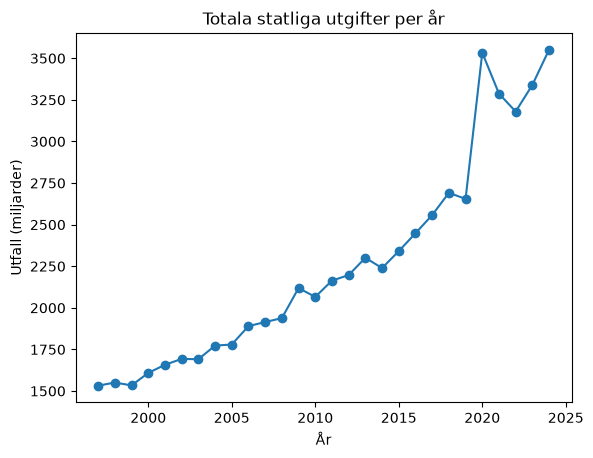

In [272]:
pd.options.display.float_format = '{:,.0f}'.format
df["Utfall_mdr"] = df["Utfall"] / 1_000
import matplotlib.pyplot as plt

yearly = df.groupby("År")["Utfall_mdr"].sum()

yearly.plot(marker="o")
plt.ylabel("Utfall (miljarder)")
plt.title("Totala statliga utgifter per år")
plt.show()

In [273]:
df.groupby("Utgiftsområdesnamn")["Utfall_mdr"].sum().sort_values(ascending=False).head(10)

Utgiftsområdesnamn
Utgiftstak                                                31,097
Ålderspensionssystemet vid sidan av statens budget         6,538
Ekonomisk trygghet vid sjukdom och funktionsnedsättning    2,894
Allmänna bidrag till kommuner                              2,830
Ekonomisk trygghet för familjer och barn                   2,051
Arbetsmarknad och arbetsliv                                1,961
Hälsovård, sjukvård och social omsorg                      1,690
Utbildning och universitetsforskning                       1,584
Försvar och samhällets krisberedskap                       1,505
Kommunikationer                                            1,261
Name: Utfall_mdr, dtype: float64

In [274]:
area_year = (
    df.groupby(["År", "Utgiftsområdesnamn"])["Utfall_mdr"]
    .sum()
    .reset_index()
)
pivot = area_year.pivot(
    index="År",
    columns="Utgiftsområdesnamn",
    values="Utfall_mdr"
).fillna(0)
growth = (pivot.loc[pivot.index.max()] - pivot.loc[pivot.index.min()])
fastest_growing = growth.sort_values(ascending=False)
print(fastest_growing.head(10))


Utgiftsområdesnamn
Utgiftstak                                                1,024
Ålderspensionssystemet vid sidan av statens budget          237
Hälsovård, sjukvård och social omsorg                        92
Allmänna bidrag till kommuner                                87
Försvar och samhällets krisberedskap                         87
Ekonomisk trygghet vid sjukdom och funktionsnedsättning      84
Utbildning och universitetsforskning                         73
Ekonomisk trygghet för familjer och barn                     64
Rättsväsendet                                                58
Kommunikationer                                              57
dtype: float64


In [275]:
from sklearn.linear_model import LinearRegression

years = pivot.index.values.reshape(-1, 1)

slopes = {}

for col in pivot.columns:
    y = pivot[col].values
    mask = ~np.isnan(y)

    if mask.sum() < 5:
        continue

    model = LinearRegression()
    model.fit(years[mask], y[mask])

    slopes[col] = model.coef_[0]

slopes = pd.Series(slopes).sort_values(ascending=False)
print(slopes.head(10))

Utgiftstak                                           38
Ålderspensionssystemet vid sidan av statens budget    9
Marginal till utgiftstaket                            4
Hälsovård, sjukvård och social omsorg                 4
Allmänna bidrag till kommuner                         3
Utbildning och universitetsforskning                  3
Ekonomisk trygghet för familjer och barn              2
Kommunikationer                                       2
Rättsväsendet                                         2
Försvar och samhällets krisberedskap                  2
dtype: float64


In [276]:
share = pivot.div(pivot.sum(axis=1), axis=0)
#share.sum(axis=1).head()
#share.describe().T.head()
#trend = share.apply(lambda x: np.mean(np.diff(x)))
#trend.sort_values(ascending=False).head(10)
#share.std().sort_values(ascending=False).head(10)
pivot.notna().mean().sort_values().head(10)

Utgiftsområdesnamn
Allmänna bidrag till kommuner                             1
Arbetsmarknad och arbetsliv                               1
Areella näringar, landsbygd och livsmedel                 1
Avgiften till Europeiska unionen                          1
Ekonomisk trygghet för familjer och barn                  1
Ekonomisk trygghet vid sjukdom och funktionsnedsättning   1
Ekonomisk trygghet vid ålderdom                           1
Energi                                                    1
Försvar och samhällets krisberedskap                      1
Förändring av anslagsbehållningar                         1
dtype: float64

In [277]:
df_filtered = df[
    ~df["Utgiftsområdesnamn"].str.contains("tak", case=False, na=False) &
    ~df["Utgiftsområdesnamn"].str.contains("korrigering", case=False, na=False) &
    ~df["Utgiftsområdesnamn"].str.contains("nettoutlåning", case=False, na=False)
]
long = df_filtered.groupby(["År", "Utgiftsområdesnamn"])["Utfall_mdr"].sum().reset_index()
long.groupby("Utgiftsområdesnamn")["Utfall_mdr"].std().sort_values(ascending=False).head(10)

Utgiftsområdesnamn
Ålderspensionssystemet vid sidan av statens budget        77
Allmänna bidrag till kommuner                             32
Hälsovård, sjukvård och social omsorg                     31
Statsskuldsräntor m.m.                                    30
Utbildning och universitetsforskning                      22
Ekonomisk trygghet vid sjukdom och funktionsnedsättning   21
Ekonomisk trygghet för familjer och barn                  20
Försvar och samhällets krisberedskap                      19
Kommunikationer                                           18
Rättsväsendet                                             15
Name: Utfall_mdr, dtype: float64

In [278]:
pivot = df_filtered.pivot_table(
    index="År",
    columns="Utgiftsområdesnamn",
    values="Utfall_mdr",
    aggfunc="sum"
).fillna(0)
trend = pivot.diff().mean().sort_values(ascending=False)
trend.head(10)

Utgiftsområdesnamn
Ålderspensionssystemet vid sidan av statens budget        9
Hälsovård, sjukvård och social omsorg                     3
Allmänna bidrag till kommuner                             3
Försvar och samhällets krisberedskap                      3
Ekonomisk trygghet vid sjukdom och funktionsnedsättning   3
Utbildning och universitetsforskning                      3
Ekonomisk trygghet för familjer och barn                  2
Rättsväsendet                                             2
Kommunikationer                                           2
Internationellt bistånd                                   1
dtype: float64

In [279]:
df_filtered["Utgiftsområdesnamn"].unique()

<StringArray>
[                      'Ålderspensionssystemet vid sidan av statens budget',
                                        'Förändring av anslagsbehållningar',
                                                          'Rikets styrelse',
                                    'Samhällsekonomi och finansförvaltning',
                                                            'Rättsväsendet',
                                                'Skatt, tull och exekution',
                                                 'Internationell samverkan',
                                                  'Internationellt bistånd',
                                                               'Näringsliv',
                                     'Försvar och samhällets krisberedskap',
                                    'Hälsovård, sjukvård och social omsorg',
                                              'Arbetsmarknad och arbetsliv',
                                                          'Kom

<Axes: xlabel='År'>

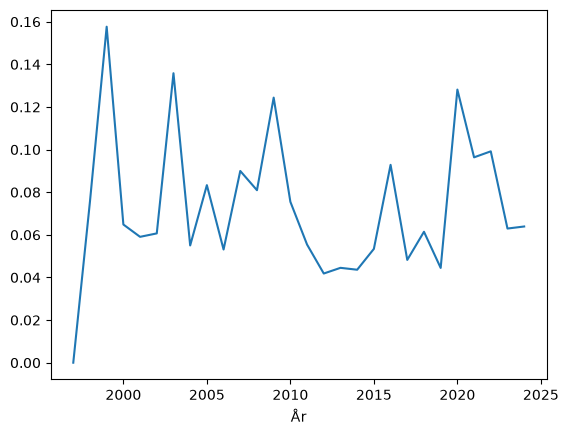

In [280]:
base = df_filtered.groupby(["År", "Utgiftsområdesnamn"])["Utfall_mdr"].sum().reset_index()

pivot = base.pivot(index="År", columns="Utgiftsområdesnamn", values="Utfall_mdr").fillna(0)

share = pivot.div(pivot.sum(axis=1), axis=0)

yearly_shift = share.diff().abs().sum(axis=1)
yearly_shift.plot()

In [281]:
net_shift = share.iloc[-1] - share.iloc[0]
net_shift.sort_values(ascending=False).head(10)

Utgiftsområdesnamn
Ålderspensionssystemet vid sidan av statens budget        0
Hälsovård, sjukvård och social omsorg                     0
Utbildning och universitetsforskning                      0
Ekonomisk trygghet vid sjukdom och funktionsnedsättning   0
Försvar och samhällets krisberedskap                      0
Rättsväsendet                                             0
Kommunikationer                                           0
Internationellt bistånd                                   0
Ekonomisk trygghet för familjer och barn                  0
Klimat, miljö och natur                                   0
dtype: float64

In [282]:
volatility = share.std()
volatility.sort_values(ascending=False).head(10)

Utgiftsområdesnamn
Statsskuldsräntor m.m.                                    0
Ålderspensionssystemet vid sidan av statens budget        0
Ekonomisk trygghet vid sjukdom och funktionsnedsättning   0
Allmänna bidrag till kommuner                             0
Hälsovård, sjukvård och social omsorg                     0
Ekonomisk trygghet vid ålderdom                           0
Arbetsmarknad och arbetsliv                               0
Utbildning och universitetsforskning                      0
Kommunikationer                                           0
Migration                                                 0
dtype: float64

In [284]:
import os
import matplotlib.pyplot as plt

rename_map = {
    "Ålderspensionssystemet vid sidan av statens budget": "Pension",
    "Ekonomisk trygghet vid sjukdom och funktionsnedsättning": "Sjukförmåner + LSS",
    "Utbildning och universitetsforskning": "Utbildning + forskning",
    "Samhällsplanering, bostadsförsörjning och byggande samt konsumentpolitik": "Samhällsplanering"
}

df_filtered["Utgiftsområdesnamn"] = df_filtered["Utgiftsområdesnamn"].replace(rename_map)

base = df_filtered.groupby(["År", "Utgiftsområdesnamn"])["Utfall"].sum().reset_index()
pivot = base.pivot(index="År", columns="Utgiftsområdesnamn", values="Utfall").fillna(0)
share = pivot.div(pivot.sum(axis=1), axis=0)

events = {
    2001: "Dot-com",
    2008: "Finanskris",
    2015: "Migrationsvåg",
    2020: "COVID-19"
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "svg.fonttype": "none"
})

fig, ax = plt.subplots(
    figsize=(16, max(8, len(share.columns) * 0.4))
)

# ---------------------------
# FIX: proper pcolormesh grid
# ---------------------------
x = range(len(share.index) + 1)
y = range(len(share.columns) + 1)

im = ax.pcolormesh(
    x,
    y,
    share.T.values,
    cmap="viridis",
    shading="auto"
)

# ---------------------------
# AXES (FIXED ALIGNMENT)
# ---------------------------
# deaktivera native ticks vi ritar egna nedan
ax.set_xticks([])
ax.set_xticklabels([])

ax.set_yticks([i + 0.5 for i in range(len(share.columns))])
ax.set_yticklabels(share.columns, rotation=45, ha="right")

# ---------------------------
# YEAR LABELS BELOW GRID
# ---------------------------
for i, year in enumerate(share.index):
    is_upper = i % 2 == 0
    y_text = -0.02 if is_upper else -0.04

    ax.text(
        i + 0.5,
        y_text,
        str(year),
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=9
    )

    ax.plot(
        [i + 0.5, i + 0.5],
        [0.0, y_text + 0.01],
        transform=ax.get_xaxis_transform(),
        color="black",
        linewidth=1,
        clip_on=False
    )

# ---------------------------
# EVENTS (FIXED POSITIONING)
# ---------------------------
years = list(share.index)

for year, label in events.items():
    if year in years:
        x_pos = years.index(year) + 0.5

        ax.axvline(
            x=x_pos,
            color="red",
            linestyle="--",
            linewidth=1
        )

        ax.text(
            x_pos - 0,
            -2,
            label,
            color="red",
            fontsize=9,
            ha="center"
        )

# ---------------------------
# STYLE
# ---------------------------
fig.colorbar(im, ax=ax, label="Andel av total budget")

# ax.set_title(
#     "Utgiftsområdenas andel av de samlade utgifter",
#     pad=20
# )
fig.suptitle("Utgiftsområdenas andel av de samlade utgifter")
plt.tight_layout()

# ---------------------------
# EXPORT (Commons-safe)
# ---------------------------
save_commons_svg(
    fig,
    "statsbudget_utgifter.svg",
    title="Utgiftsområdenas andel av de samlade utgifter",
    description="Andel av statens budget per utgiftsområde och år"
)
plt.close(fig)

Saved Commons SVG to: output/statsbudget_utgifter.svg


Saved Commons SVG to: output/statliga_utgifter_och_forandring.svg


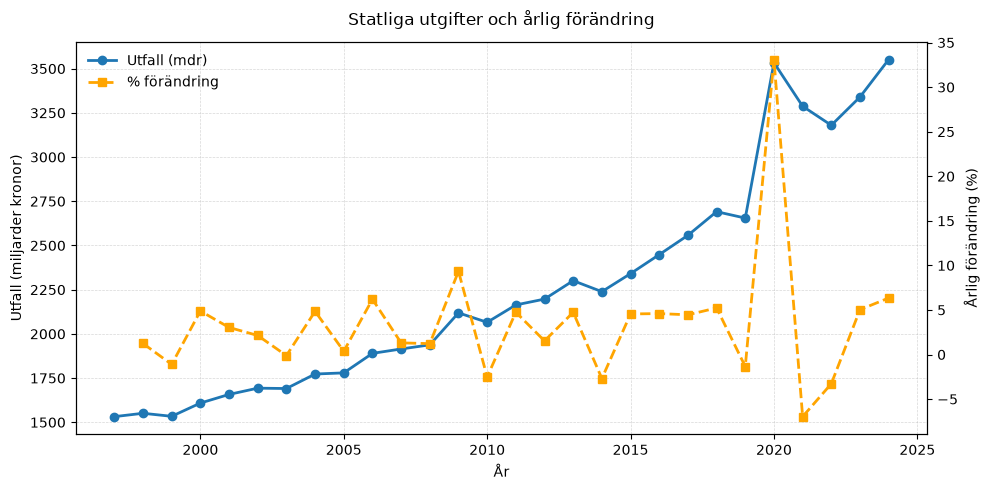

Saved: statliga_utgifter_och_forandring.svg


In [287]:
import matplotlib.pyplot as plt

yearly = df.groupby("År")["Utfall_mdr"].sum().sort_index()
pct_change = yearly.pct_change() * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

# --- nivå (huvudserie)
ax1.plot(
    yearly.index,
    yearly.values,
    marker="o",
    linewidth=2,
    label="Utfall (mdr)"
)
ax1.set_ylabel("Utfall (miljarder kronor)")
ax1.set_xlabel("År")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# --- % förändring (sekundär axel)
ax2 = ax1.twinx()
ax2.plot(
    pct_change.index,
    pct_change.values,
    marker="s",
    linestyle="--",
    linewidth=2,
    color="orange",
    label="% förändring"
)
ax2.set_ylabel("Årlig förändring (%)")

# --- gemensam legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

# --- titel
plt.title("Statliga utgifter och årlig förändring", pad=12)

plt.tight_layout()

# --- export för Wikimedia Commons
out_path = "statliga_utgifter_och_forandring.svg"
save_commons_svg(fig, out_path, title="Statliga utgifter 1997-2024", description=(
    "Utveckling av svenska statens utgifter i miljarder kronor samt årlig procentuell förändring. "
    "Tidsserie visar både absolut nivå och förändringstakt över tid. Källa: Statskontoret."
))

plt.show()

print("Saved:", out_path)

Saved Commons SVG to: output/statliga_utgifter_och_forandring_split.svg


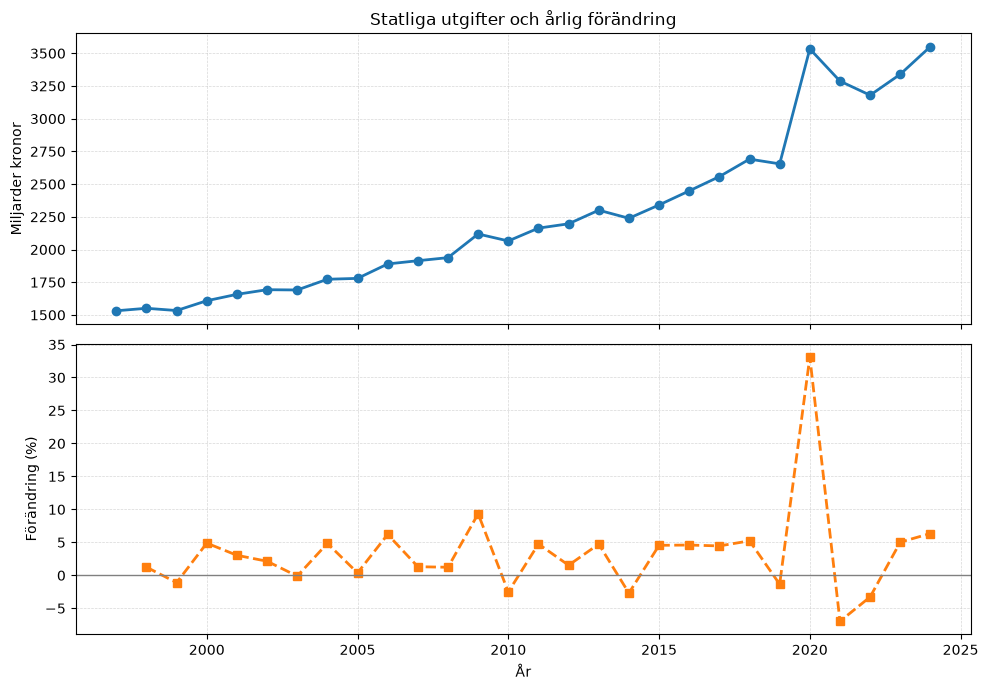

Saved: statliga_utgifter_och_forandring_split.svg


In [288]:
import matplotlib.pyplot as plt

yearly = df.groupby("År")["Utfall_mdr"].sum().sort_index()
pct_change = yearly.pct_change() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- 1: nivå (mdr)
ax1.plot(
    yearly.index,
    yearly.values,
    marker="o",
    linewidth=2,
    color="tab:blue"
)
ax1.set_title("Statliga utgifter 1997-2024")
ax1.set_ylabel("Miljarder kronor")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# --- 2: procent
ax2.plot(
    pct_change.index,
    pct_change.values,
    marker="s",
    linestyle="--",
    linewidth=2,
    color="tab:orange"
)
ax2.axhline(0, color="gray", linewidth=1)
ax2.set_ylabel("Förändring (%)")
ax2.set_xlabel("År")
ax2.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()

# --- export (Wikimedia Commons)
out_path = "statliga_utgifter_och_forandring_split.svg"
save_commons_svg(fig, out_path, title="Statliga utgifter 1997-2024", description=(
    "Utveckling av svenska statens utgifter i miljarder kronor samt årlig procentuell förändring. Tidsserien visar både absolut nivå och förändringstakt över tid. Källa: Statskontoret."
))

plt.show()

print("Saved:", out_path)